In [1]:
# Perform imports and load the dataset:
import pandas as pd

In [2]:
df = pd.read_csv("Processed_Reviews.csv",encoding="ISO-8859-1")
df.shape

(13, 14)

In [3]:
df.head()

,Review,lowercased,urls_removed,html_removed,emojis_removed,slangs_replaced,contractions_replaced,punctuations_removed,numbers_removed,spelling_corrected,stopwords_removed,stemmed_words,lemmatized,tokenized
0,The product arrived on time. Packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time. packaging was gre...,the product arrived on time packaging was grea...,the product arrived on time packaging was grea...,the product arrived on time packaging was grea...,product arrived time packaging great quality a...,product arriv time packag great qualiti amaz,product arrive time packaging great quality am...,"['product', 'arrive', 'time', 'packaging', 'gr..."
1,THIS PRODUCT IS JUST AMAZING! I LOVE IT.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing i love it,this product is just amazing i love it,this product is just amazing i love it,product amazing love,product amaz love,product amaze love,"['product', 'amaze', 'love']"
2,"I bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...","i bought this phone for $799, and it has a 120...",i bought this phone for 799 and it has a 120hz...,i bought this phone for and it has a hz displ...,i bought this phone for and it has a hz displ...,bought phone hz display totally worth,bought phone hz display total worth,buy phone hz display totally worth,"['buy', 'phone', 'hz', 'display', 'totally', '..."
3,Wow!!! This product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow!!! this product is awesome... but a bit ex...,wow this product is awesome but a bit expensive,wow this product is awesome but a bit expensive,wow this product is awesome but a bit expensive,wow product awesome bit expensive,wow product awesom bit expens,wow product awesome bit expensive,"['wow', 'product', 'awesome', 'bit', 'expensive']"
4,The laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine,the laptop works perfectly fine,the laptop works perfectly fine,laptop works perfectly fine,laptop work perfectli fine,laptop work perfectly fine,"['laptop', 'work', 'perfectly', 'fine']"


In [4]:
# Checking for null values
df.isnull().sum()

Review                   0
lowercased               0
urls_removed             0
html_removed             0
emojis_removed           0
slangs_replaced          0
contractions_replaced    0
punctuations_removed     0
numbers_removed          0
spelling_corrected       0
stopwords_removed        0
stemmed_words            0
lemmatized               0
tokenized                0
dtype: int64

In [5]:
# Checking Duplicate values
df.duplicated().sum()

np.int64(0)

In [6]:
text_col = "lemmatized"

#Keep only the review text column
df = df[[text_col]].copy()

#Rename 
df.rename(columns={text_col: "review"}, inplace=True)

#Create empty label column
df["label"] = ""

print(df.head())

                                              review label
0  product arrive time packaging great quality am...      
1                                 product amaze love      
2                 buy phone hz display totally worth      
3                  wow product awesome bit expensive      
4                         laptop work perfectly fine      


In [7]:
df.loc[0, "label"] = 1  
df.loc[1, "label"] = 1   
df.loc[2, "label"] = 1  
df.loc[3, "label"] = 1   
df.loc[4, "label"] = 1  
df.loc[5, "label"] = 1   
df.loc[6, "label"] = 1  
df.loc[7, "label"] = 0 
df.loc[8, "label"] = 1  
df.loc[9, "label"] = 1   
df.loc[10, "label"] = 1  
df.loc[11, "label"] = 1  
df.loc[12, "label"] = 1  

In [8]:
print(df.head())

                                              review label
0  product arrive time packaging great quality am...     1
1                                 product amaze love     1
2                 buy phone hz display totally worth     1
3                  wow product awesome bit expensive     1
4                         laptop work perfectly fine     1


In [9]:
print(df['label'].head())
print(df['label'].dtype)

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: object
object


In [10]:
df['label'] = pd.to_numeric(df['label'], errors='coerce')

In [11]:
print(df['label'].dtype)
print(df['label'].value_counts())

int64
label
1    12
0     1
Name: count, dtype: int64


In [12]:
# import library
import re
import string
import nltk
from nltk.corpus import stopwords

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vect = TfidfVectorizer()

X = tfidf_vect.fit_transform(df['review'])
y = df['label']

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [15]:
# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [16]:
df = df.dropna(subset=['review', 'label'])
df['label'] = df['label'].astype(int)

In [17]:
# Naive Bayes
nb_clf = MultinomialNB().fit(X_train, y_train)

# SVM
svm_clf = SVC(kernel='linear').fit(X_train, y_train)

In [18]:
# Performance metrics comparison
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score # Importing accuracy_score

# Naive Bayes
nb_predicted = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_predicted)
# Calculate error rate for Naive Bayes
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted)
nb_cm = confusion_matrix(y_test, nb_predicted)

# SVM
svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)
# Calculate error rate for SVM
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
svm_cm = confusion_matrix(y_test, svm_predicted)
nb_cm

C:\Users\adamz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\adamz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


array([[4]])

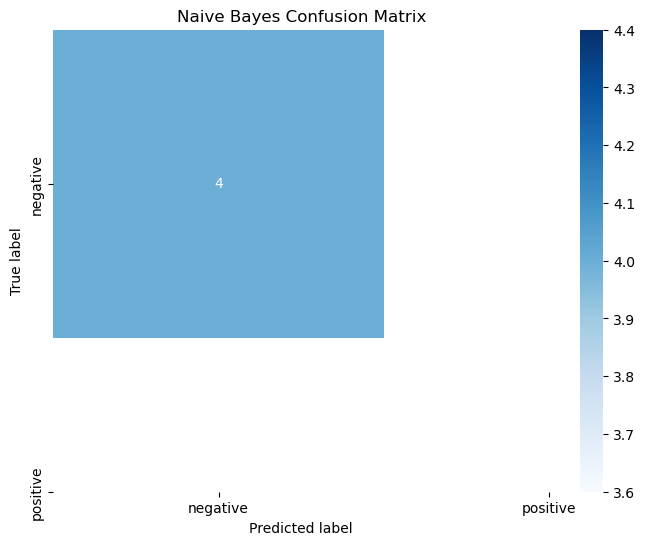

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Naive Bayes Error Rate: 0.00


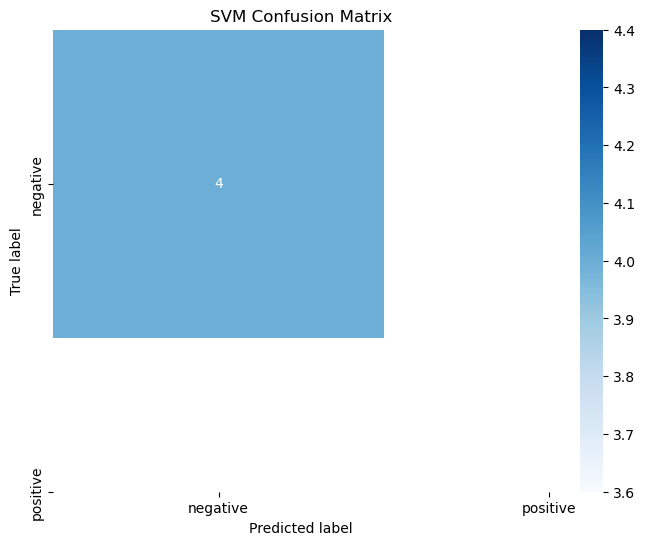


SVM Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Error Rate: 0.00


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    
# Plot confusion matrix for Naive Bayes
plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')

print("Naive Bayes Classifier Report:")
print(nb_report)
print(f"\nNaive Bayes Error Rate: {nb_error_rate:.2f}")
                      
# Plot confusion matrix for SVM
plot_confusion_matrix(svm_cm, classes=['negative', 'positive'], title='SVM Confusion Matrix')
                      
print("\nSVM Classifier Report:")
print(svm_report)
print(f"\nSVM Error Rate: {svm_error_rate:.2f}")